In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
#LOAD DATASET
df = pd.read_csv('DATASET\Crop_recommendation.csv')

# Tampilkan 5 data pertama
df.head()


<>:2: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:2: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\Abim Putra\AppData\Local\Temp\ipykernel_21520\1804055045.py:2: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df = pd.read_csv('DATASET\Crop_recommendation.csv')


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


--------------------------------------------------MASUK PREPROCESSING DATA-------------------------------------------------

Shape dataset: (2200, 8)

Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB
None

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Statistik deskriptif:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.14909

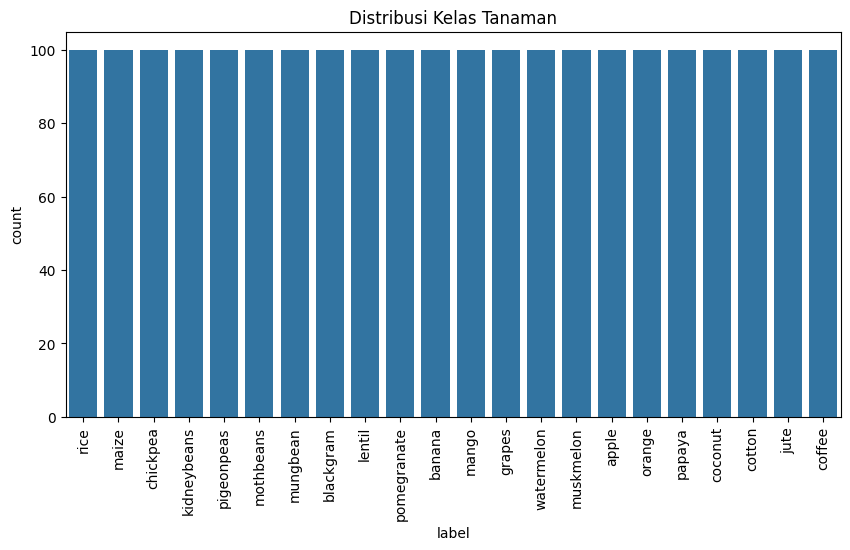

In [3]:
#Eksplorasi Data

print("Shape dataset:", df.shape)
print("\nInfo dataset:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistik deskriptif:")
print(df.describe())

# Distribusi kelas
plt.figure(figsize=(10,5))
sns.countplot(x="label", data=df)
plt.xticks(rotation=90)
plt.title("Distribusi Kelas Tanaman")
plt.show()

In [4]:
X = df.drop("label", axis=1)
y = df["label"]

le = LabelEncoder()
y = le.fit_transform(df["label"])


In [5]:
# Split data menjadi training dan testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [6]:
#SCALING FITUR NUMERIK

scaler_baseline = StandardScaler()
X_train_scaled_base = scaler_baseline.fit_transform(X_train)
X_test_scaled_base = scaler_baseline.transform(X_test)



In [7]:
#Tampilkan ukuran data setelah preprocessing

print("Ukuran X_train:", X_train_scaled_base.shape)
print("Ukuran X_test :", X_test_scaled_base.shape)
print("Jumlah kelas :", len(np.unique(y)))

Ukuran X_train: (1760, 7)
Ukuran X_test : (440, 7)
Jumlah kelas : 22


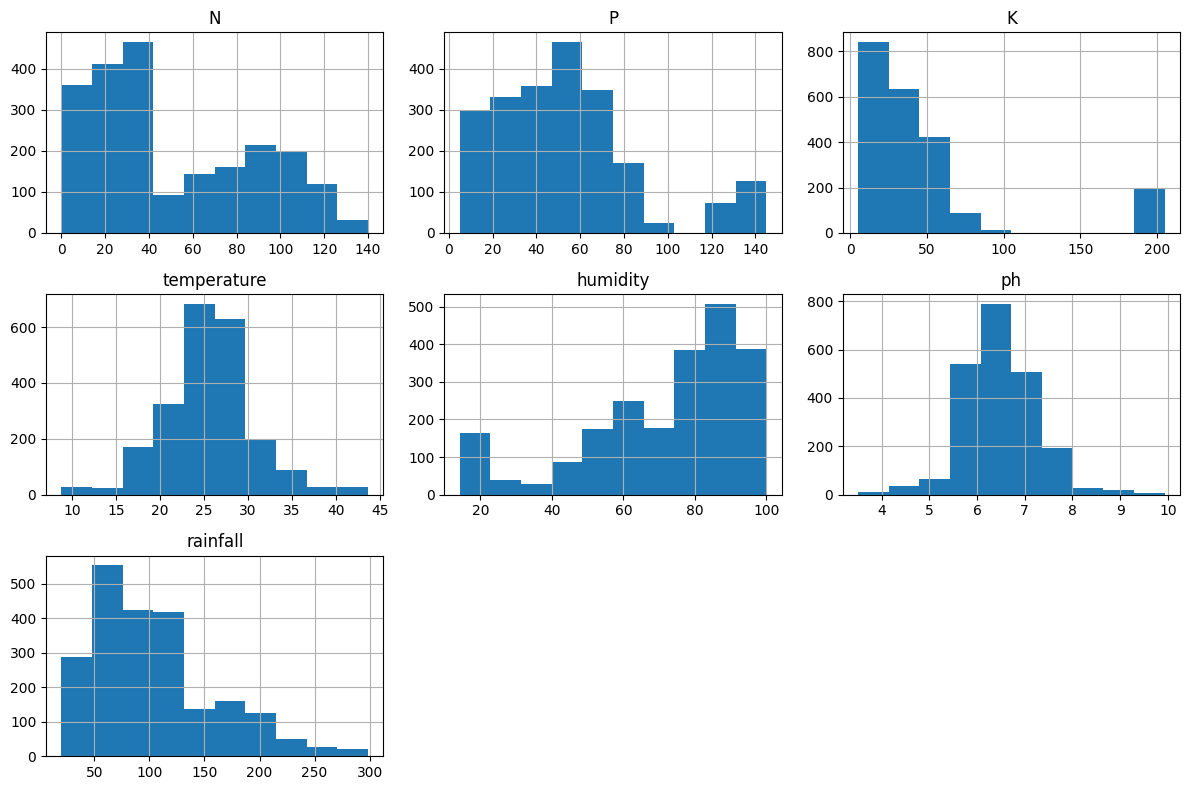

In [8]:
#Visualisasi distribusi fitur numerik setelah scaling

import matplotlib.pyplot as plt

df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


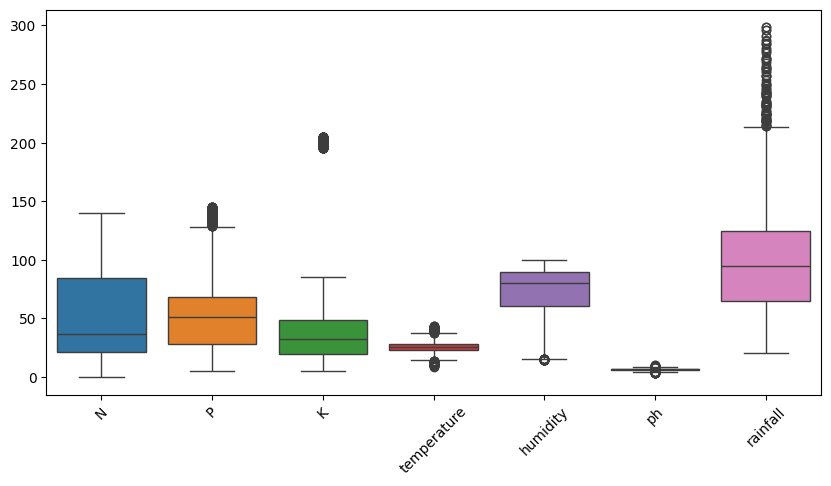

In [9]:
#Visualisasi boxplot untuk mendeteksi outlier pada fitur numerik

import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=df.drop(columns="label"))
plt.xticks(rotation=45)
plt.show()


In [10]:
#Tampilkan fitur yang digunakan untuk modeling

feature_names = X_train.columns.tolist()



# sebelum scaling
before = pd.DataFrame(X_train, columns=feature_names)

# sesudah scaling
after = pd.DataFrame(X_train_scaled_base, columns=feature_names)

selected_features = ["temperature", "rainfall", "humidity"]


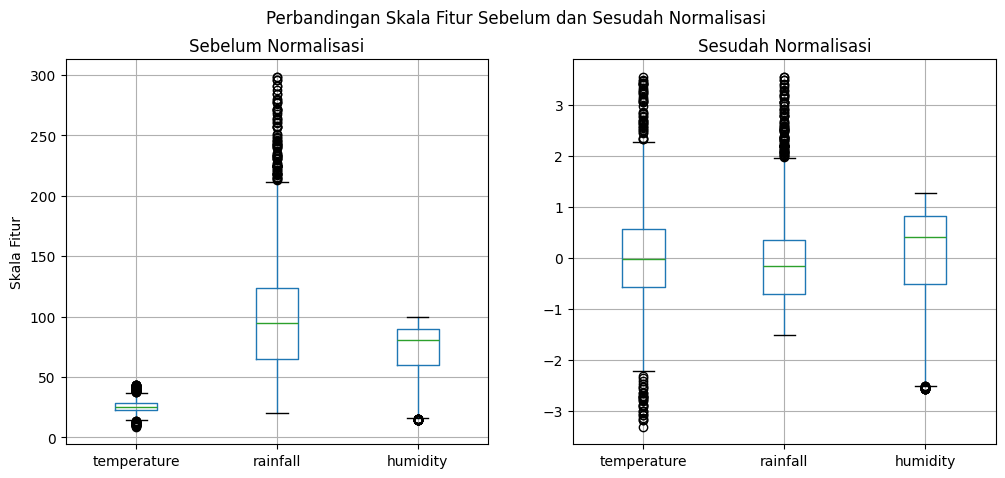

In [11]:
#Visualisasi boxplot untuk membandingkan skala fitur sebelum dan sesudah normalisasi

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before normalization
before[selected_features].boxplot(ax=axes[0])
axes[0].set_title("Sebelum Normalisasi")
axes[0].set_ylabel("Skala Fitur")

# After normalization
after[selected_features].boxplot(ax=axes[1])
axes[1].set_title("Sesudah Normalisasi")

plt.suptitle("Perbandingan Skala Fitur Sebelum dan Sesudah Normalisasi")
plt.show()


------------------------------------------------MASUK KOMPARASI MODEL BASELINE---------------------------------------------

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay



In [13]:
def get_models_classification():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(
            n_estimators=100, random_state=42
        ),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "SVM": SVC(kernel="rbf", probability=True),
        "XGBoost": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    )
}


In [14]:

results = []
trained_models_baseline = {} 
models_baseline = get_models_classification()


In [15]:
results = []

for name, model in models_baseline.items():
        model.fit(X_train_scaled_base, y_train)
        trained_models_baseline[name] = model
        y_pred = model.predict(X_test_scaled_base)

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average="weighted"),
            "Recall": recall_score(y_test, y_pred, average="weighted"),
            "F1-Score": f1_score(y_test, y_pred, average="weighted")
        })

baseline_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
baseline_df


,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.995455,0.995671,0.995455,0.995452
5,XGBoost,0.993182,0.993506,0.993182,0.993116
4,SVM,0.984091,0.985610,0.984091,0.984038
1,Decision Tree,0.979545,0.980598,0.979545,0.979423
3,KNN,0.979545,0.980356,0.979545,0.979283
0,Logistic Regression,0.972727,0.974022,0.972727,0.972464


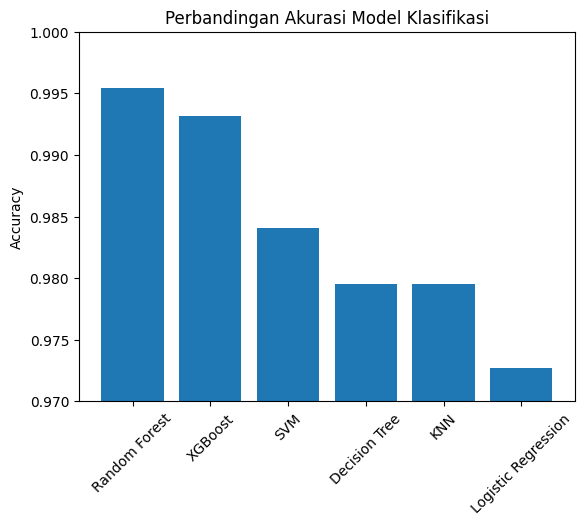

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(baseline_df["Model"], baseline_df["Accuracy"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Perbandingan Akurasi Model Klasifikasi")
plt.ylim(0.97, 1.0) 
plt.show()


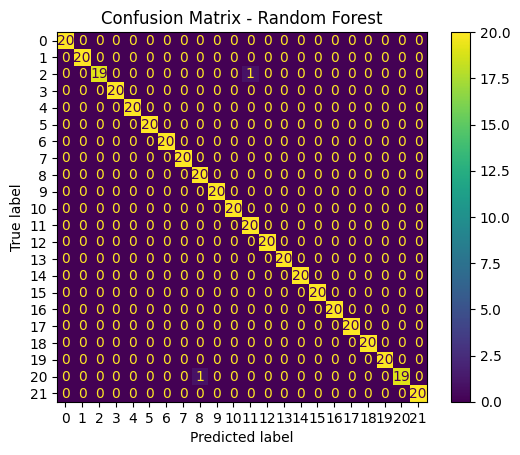

In [17]:
best_model_name = baseline_df.iloc[0]["Model"]
best_model = trained_models_baseline[best_model_name]

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_scaled_base,
    y_test
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


--------------------------------------------------MASUK FEATURE SELECTION-------------------------------------------------

Fitur dengan korelasi > 0.8: []


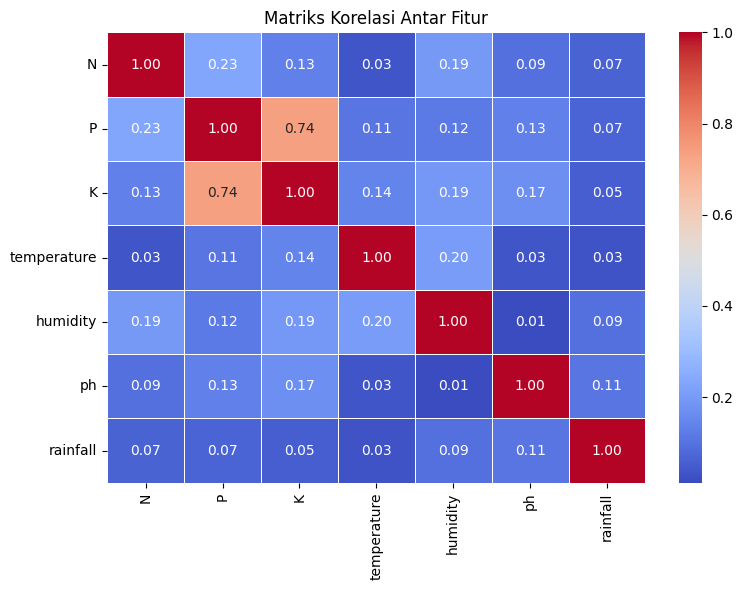

In [18]:
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.8
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

print("Fitur dengan korelasi > 0.8:", to_drop)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriks Korelasi Antar Fitur")
plt.tight_layout()
plt.show()

In [19]:
rf_fs = RandomForestClassifier(random_state=42)
rf_fs.fit(X_train, y_train)

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_fs.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
6,rainfall,0.230184
4,humidity,0.224227
2,K,0.175393
1,P,0.150850
0,N,0.096363
3,temperature,0.072375
5,ph,0.050608


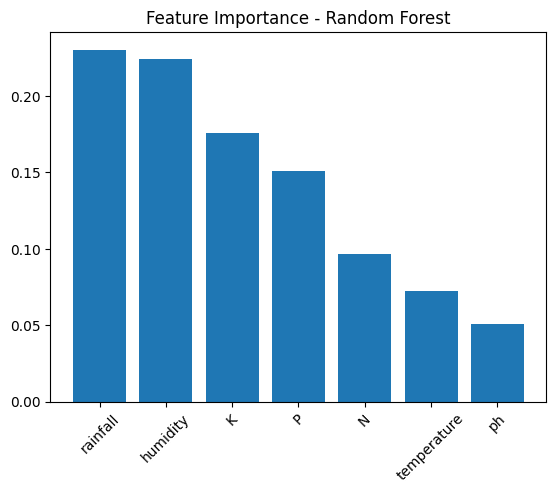

In [20]:
plt.figure()
plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance - Random Forest")
plt.show()


In [21]:
threshold = feature_importance_df["Importance"].mean()

selected_features = feature_importance_df[
    feature_importance_df["Importance"] >= threshold
]["Feature"].tolist()

selected_features


['rainfall', 'humidity', 'K', 'P']

In [22]:
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

scaler_fs = StandardScaler()
X_train_scaled_fs = scaler_fs.fit_transform(X_train_sel)
X_test_scaled_fs = scaler_fs.transform(X_test_sel)


In [23]:
fs_results = []
trained_models_fs = {}
models_fs = get_models_classification()

In [24]:
fs_results = []

for name, model in models_fs.items():
    model.fit(X_train_scaled_fs, y_train)
    trained_models_fs[name] = model 
    y_pred = model.predict(X_test_scaled_fs)

    fs_results.append({
        "Model": name,
        "Accuracy_FS": accuracy_score(y_test, y_pred),
        "Precision_FS": precision_score(y_test, y_pred, average="weighted"),
        "Recall_FS": recall_score(y_test, y_pred, average="weighted"),
        "F1_FS": f1_score(y_test, y_pred, average="weighted")
    })

fs_df = pd.DataFrame(fs_results)
fs_df


,Model,Accuracy_FS,Precision_FS,Recall_FS,F1_FS
0,Logistic Regression,0.945455,0.945911,0.945455,0.944086
1,Decision Tree,0.954545,0.959206,0.954545,0.956183
2,Random Forest,0.977273,0.978872,0.977273,0.977509
3,KNN,0.961364,0.961555,0.961364,0.958800
4,SVM,0.977273,0.979280,0.977273,0.977029
5,XGBoost,0.959091,0.959911,0.959091,0.958764


In [25]:
comparison_fs = baseline_df.merge(fs_df, on="Model")

comparison_fs["Accuracy Change"] = comparison_fs["Accuracy_FS"] - comparison_fs["Accuracy"]
comparison_fs["Precision Change"] = comparison_fs["Precision_FS"] - comparison_fs["Precision"]
comparison_fs["Recall Change"] = comparison_fs["Recall_FS"] - comparison_fs["Recall"]
comparison_fs["F1 Change"] = comparison_fs["F1_FS"] - comparison_fs["F1-Score"]

comparison_fs


,Model,Accuracy,Precision,Recall,F1-Score,Accuracy_FS,Precision_FS,Recall_FS,F1_FS,Accuracy Change,Precision Change,Recall Change,F1 Change
0,Random Forest,0.995455,0.995671,0.995455,0.995452,0.977273,0.978872,0.977273,0.977509,-0.018182,-0.016799,-0.018182,-0.017943
1,XGBoost,0.993182,0.993506,0.993182,0.993116,0.959091,0.959911,0.959091,0.958764,-0.034091,-0.033595,-0.034091,-0.034352
2,SVM,0.984091,0.985610,0.984091,0.984038,0.977273,0.979280,0.977273,0.977029,-0.006818,-0.006330,-0.006818,-0.007009
3,Decision Tree,0.979545,0.980598,0.979545,0.979423,0.954545,0.959206,0.954545,0.956183,-0.025000,-0.021392,-0.025000,-0.023241
4,KNN,0.979545,0.980356,0.979545,0.979283,0.961364,0.961555,0.961364,0.958800,-0.018182,-0.018800,-0.018182,-0.020483
5,Logistic Regression,0.972727,0.974022,0.972727,0.972464,0.945455,0.945911,0.945455,0.944086,-0.027273,-0.028111,-0.027273,-0.028378


-----------------------------------------------------MASUK LEARNING CURVE--------------------------------------------------

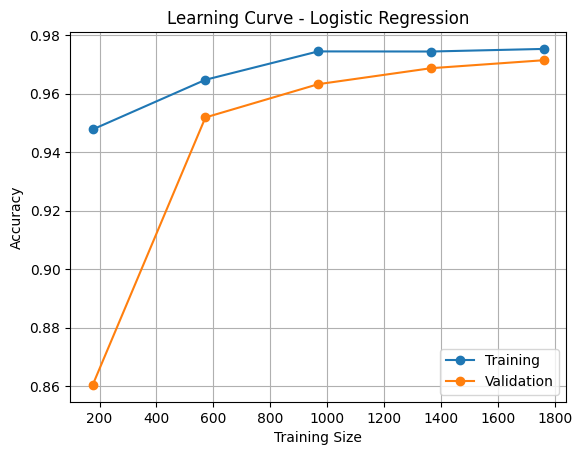

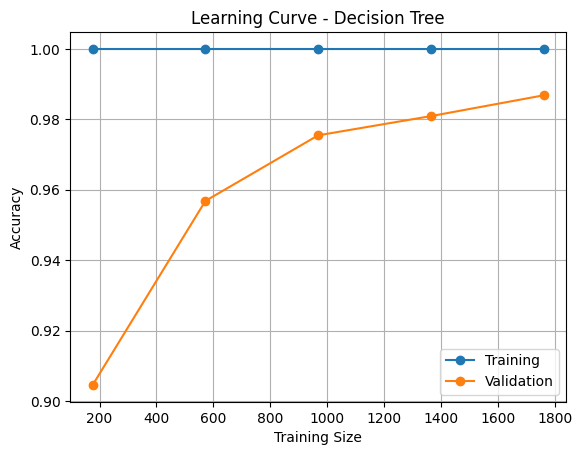

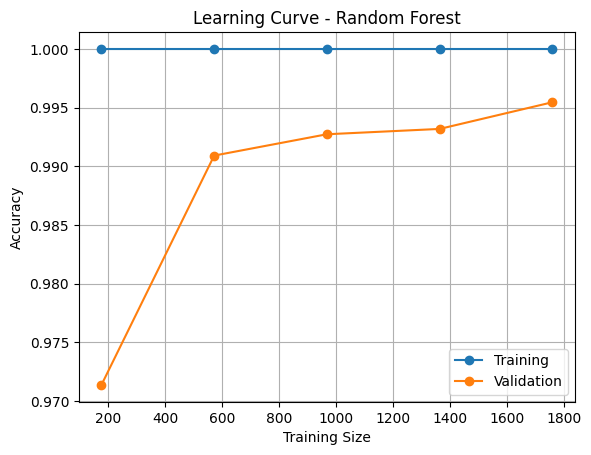

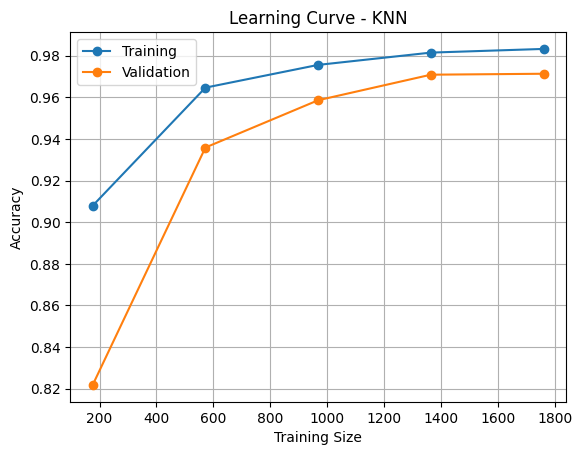

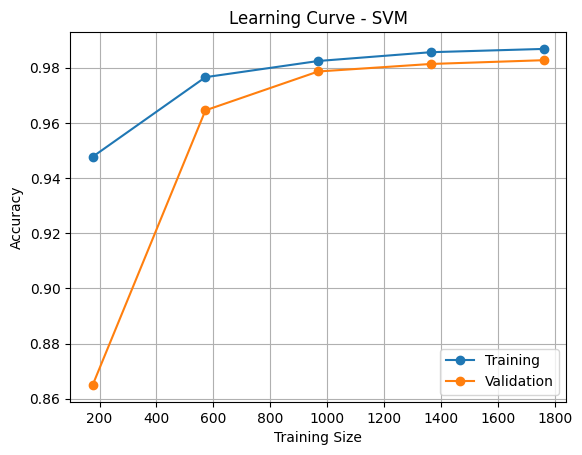

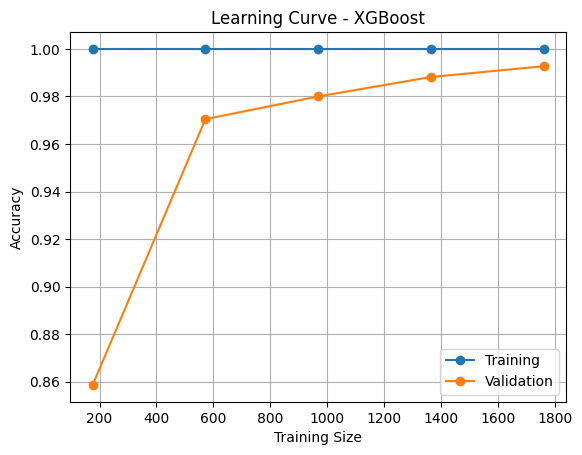


===== Learning Curve Table - Logistic Regression =====


,Train Size,Train Accuracy,Validation Accuracy,Gap
0,176,0.947727,0.860455,0.087273
1,572,0.964685,0.951818,0.012867
2,968,0.974380,0.963182,0.011198
3,1364,0.974340,0.968636,0.005704
4,1760,0.975227,0.971364,0.003864



===== Learning Curve Table - Decision Tree =====


,Train Size,Train Accuracy,Validation Accuracy,Gap
0,176,1.0,0.904545,0.095455
1,572,1.0,0.956818,0.043182
2,968,1.0,0.975455,0.024545
3,1364,1.0,0.980909,0.019091
4,1760,1.0,0.986818,0.013182



===== Learning Curve Table - Random Forest =====


...

,Train Size,Train Accuracy,Validation Accuracy,Gap
0,176,0.907955,0.821818,0.086136
1,572,0.964685,0.935909,0.028776
2,968,0.975620,0.958636,0.016983
3,1364,0.981525,0.970909,0.010616
4,1760,0.983295,0.971364,0.011932



===== Learning Curve Table - SVM =====


,Train Size,Train Accuracy,Validation Accuracy,Gap
0,176,0.947727,0.865000,0.082727
1,572,0.976573,0.964545,0.012028
2,968,0.982438,0.978636,0.003802
3,1364,0.985630,0.981364,0.004267
4,1760,0.986818,0.982727,0.004091



===== Learning Curve Table - XGBoost =====


,Train Size,Train Accuracy,Validation Accuracy,Gap
0,176,1.0,0.858636,0.141364
1,572,1.0,0.970455,0.029545
2,968,1.0,0.980000,0.020000
3,1364,1.0,0.988182,0.011818
4,1760,1.0,0.992727,0.007273


In [26]:
#LEARNING CURVE ANALYSIS

from sklearn.pipeline import Pipeline
from sklearn.model_selection import learning_curve

learning_curve_results = {}

for name, model in models_baseline.items():
    
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline,
        X,
        y,
        cv=5,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 5),
        shuffle=True,
        random_state=42
    )
    
    learning_curve_results[name] = {
        "train_sizes": train_sizes,
        "train_mean": train_scores.mean(axis=1),
        "val_mean": val_scores.mean(axis=1)
    }
    
    plt.figure()
    plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label="Training")
    plt.plot(train_sizes, val_scores.mean(axis=1), marker='o', label="Validation")
    plt.title(f"Learning Curve - {name}")
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    learning_curve_tables = {}

for name, result in learning_curve_results.items():
    
    df_lc = pd.DataFrame({
        "Train Size": result["train_sizes"],
        "Train Accuracy": result["train_mean"],
        "Validation Accuracy": result["val_mean"]
    })
    
    df_lc["Gap"] = df_lc["Train Accuracy"] - df_lc["Validation Accuracy"]
    
    learning_curve_tables[name] = df_lc
    
    print(f"\n===== Learning Curve Table - {name} =====")
    display(df_lc)


--------------------------------------------RM4------------------------------------------------------------

In [27]:
#CROSS-VALIDATION ANALYSIS

from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models_baseline.items():
    scores = cross_val_score(
        model,
        X_train_scaled_base,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    cv_results.append({
        "Model": name,
        "CV Mean": scores.mean(),
        "CV Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)
cv_df


,Model,CV Mean,CV Std
0,Logistic Regression,0.967614,0.011307
1,Decision Tree,0.984659,0.007097
2,Random Forest,0.993182,0.004252
3,KNN,0.965341,0.007495
4,SVM,0.976136,0.007538
5,XGBoost,0.988636,0.006478


In [28]:
train_results = []

for name, model in trained_models_baseline.items():
    y_train_pred = model.predict(X_train_scaled_base)
    train_acc = accuracy_score(y_train, y_train_pred)
    
    train_results.append({
        "Model": name,
        "Train Accuracy": train_acc
    })

train_df = pd.DataFrame(train_results)
train_df


,Model,Train Accuracy
0,Logistic Regression,0.973864
1,Decision Tree,1.000000
2,Random Forest,1.000000
3,KNN,0.984659
4,SVM,0.985795
5,XGBoost,1.000000


In [29]:


final_tradeoff = baseline_df.merge(cv_df, on="Model")
final_tradeoff = final_tradeoff.merge(train_df, on="Model")

final_tradeoff["Gap"] = final_tradeoff["Train Accuracy"] - final_tradeoff["Accuracy"]

final_tradeoff


,Model,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std,Train Accuracy,Gap
0,Random Forest,0.995455,0.995671,0.995455,0.995452,0.993182,0.004252,1.000000,0.004545
1,XGBoost,0.993182,0.993506,0.993182,0.993116,0.988636,0.006478,1.000000,0.006818
2,SVM,0.984091,0.985610,0.984091,0.984038,0.976136,0.007538,0.985795,0.001705
3,Decision Tree,0.979545,0.980598,0.979545,0.979423,0.984659,0.007097,1.000000,0.020455
4,KNN,0.979545,0.980356,0.979545,0.979283,0.965341,0.007495,0.984659,0.005114
5,Logistic Regression,0.972727,0.974022,0.972727,0.972464,0.967614,0.011307,0.973864,0.001136


In [30]:
final_tradeoff["Stability Score"] = final_tradeoff["CV Std"] + final_tradeoff["Gap"]

final_tradeoff.sort_values(by=["Accuracy", "Stability Score"], ascending=[False, True])


,Model,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std,Train Accuracy,Gap,Stability Score
0,Random Forest,0.995455,0.995671,0.995455,0.995452,0.993182,0.004252,1.000000,0.004545,0.008797
1,XGBoost,0.993182,0.993506,0.993182,0.993116,0.988636,0.006478,1.000000,0.006818,0.013296
2,SVM,0.984091,0.985610,0.984091,0.984038,0.976136,0.007538,0.985795,0.001705,0.009242
4,KNN,0.979545,0.980356,0.979545,0.979283,0.965341,0.007495,0.984659,0.005114,0.012608
3,Decision Tree,0.979545,0.980598,0.979545,0.979423,0.984659,0.007097,1.000000,0.020455,0.027551
5,Logistic Regression,0.972727,0.974022,0.972727,0.972464,0.967614,0.011307,0.973864,0.001136,0.012443


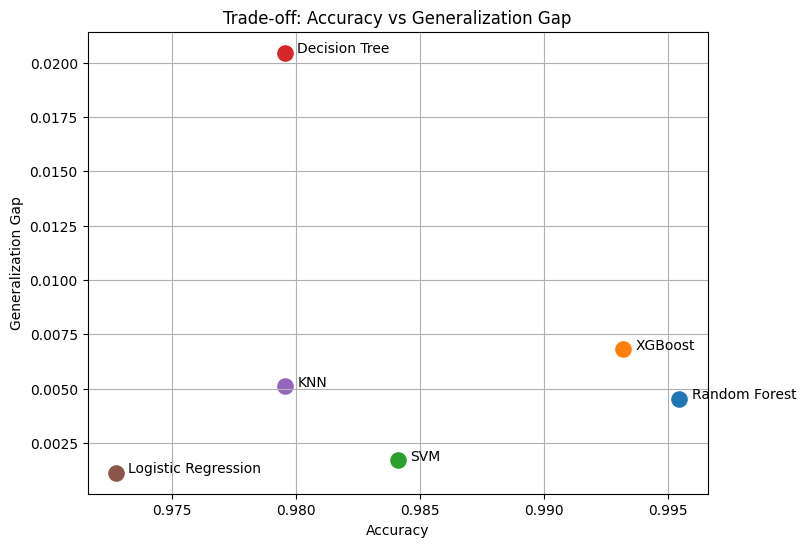

In [31]:


plt.figure(figsize=(8,6))

for i in range(len(final_tradeoff)):
    plt.scatter(
        final_tradeoff["Accuracy"][i],
        final_tradeoff["Gap"][i],
        s=120
    )
    plt.text(
        final_tradeoff["Accuracy"][i] + 0.0005,
        final_tradeoff["Gap"][i],
        final_tradeoff["Model"][i]
    )

plt.xlabel("Accuracy")
plt.ylabel("Generalization Gap")
plt.title("Trade-off: Accuracy vs Generalization Gap")
plt.grid(True)
plt.show()

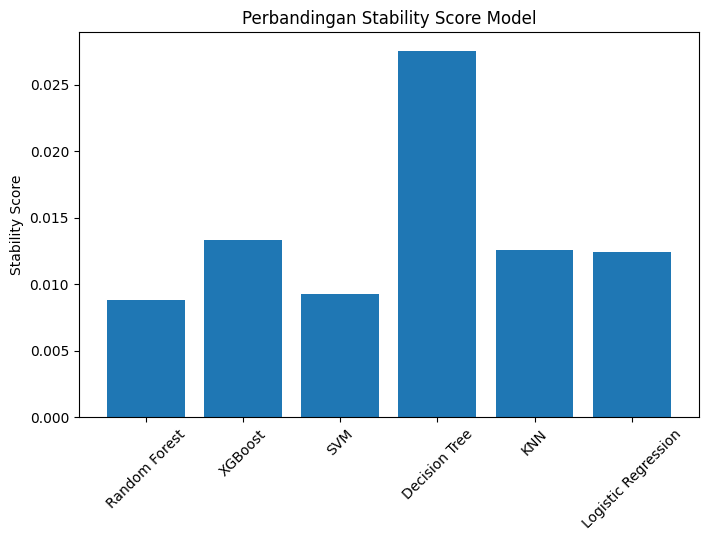

In [33]:
plt.figure(figsize=(8,5))
plt.bar(final_tradeoff["Model"], final_tradeoff["Stability Score"])
plt.xticks(rotation=45)
plt.ylabel("Stability Score")
plt.title("Perbandingan Stability Score Model")
plt.show()